In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [26]:
%pip install xgboost
%pip install catboost


Note: you may need to restart the kernel to use updated packages.


In [27]:
df=pd.read_csv("data/StudentsPerformance.csv")

In [28]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [29]:
X=df.drop(columns=['math score'],axis=1)
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [30]:
y=df['math score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [31]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

ohe=OneHotEncoder()
std=StandardScaler()

processor=ColumnTransformer(
    [
        ('OneHotEncoder',ohe,cat_features),
        ('StandardScaler',std,num_features)
    ]
)

In [32]:
num_features

Index(['reading score', 'writing score'], dtype='object')

In [33]:
X=processor.fit_transform(X)
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
X_train.shape,X_test.shape

((750, 19), (250, 19))

In [35]:
def evaluation_matrics(true,predicted):
    mse=mean_squared_error(true,predicted)
    mae=mean_absolute_error(true,predicted)
    r2s=r2_score(true,predicted)
    rmse=np.sqrt(mse)
    return mae,rmse,r2s

In [36]:
models={
    'LinearRegression':LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge(),
    'K-nearestNeighbour regressor':KNeighborsRegressor(),
    'DecissionTree':DecisionTreeRegressor(),
    'RandomForest':RandomForestRegressor(),
    'XGBoost':XGBRegressor(),
    'Catboosting regressor':CatBoostRegressor(verbose=False),
    'Adaboost':AdaBoostRegressor()
}

model_list=[]
r2s_list=[]

for i in range (len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_predict=model.predict(X_train)
    y_test_predict=model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2s=evaluation_matrics(y_train,y_train_predict)
    model_test_mae, model_test_rmse, model_test_r2s=evaluation_matrics(y_test,y_test_predict)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for training set')
    print('-Root mean squared error: {:.4f}'.format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2s))

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2s))

    r2s_list.append(model_test_r2s)

    print('='*35)
    print('\n')

    


LinearRegression
Model performance for training set
-Root mean squared error: 5.5002
- Mean Absolute Error: 4.2520
- R2 Score: 0.8738
Model performance for Test set
- Root Mean Squared Error: 5.5002
- Mean Absolute Error: 4.3515
- R2 Score: 0.8770


Lasso
Model performance for training set
-Root mean squared error: 6.6541
- Mean Absolute Error: 5.1837
- R2 Score: 0.8077
Model performance for Test set
- Root Mean Squared Error: 6.6541
- Mean Absolute Error: 5.2217
- R2 Score: 0.8200


Ridge
Model performance for training set
-Root mean squared error: 5.4788
- Mean Absolute Error: 4.2368
- R2 Score: 0.8743
Model performance for Test set
- Root Mean Squared Error: 5.4788
- Mean Absolute Error: 4.3354
- R2 Score: 0.8780


K-nearestNeighbour regressor
Model performance for training set
-Root mean squared error: 7.1380
- Mean Absolute Error: 4.5856
- R2 Score: 0.8497
Model performance for Test set
- Root Mean Squared Error: 7.1380
- Mean Absolute Error: 5.5304
- R2 Score: 0.7929


DecissionT

In [37]:
pd.DataFrame(list(zip(model_list, r2s_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.877990
0,LinearRegression,0.877034
7,Catboosting regressor,0.854830
5,RandomForest,0.847569
8,Adaboost,0.837399
6,XGBoost,0.836290
1,Lasso,0.820027
3,K-nearestNeighbour regressor,0.792903
4,DecissionTree,0.751666


## As the r2s of ridge and liniear are almost same we will consider linear regression and calculate the accuracy of the model using it

In [39]:
lin_reg=LinearRegression()
lin_model=lin_reg.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)

accuracy=r2_score(y_test,y_pred) *100

print('Accuracy of the model is %.2f'%accuracy)

Accuracy of the model is 87.70


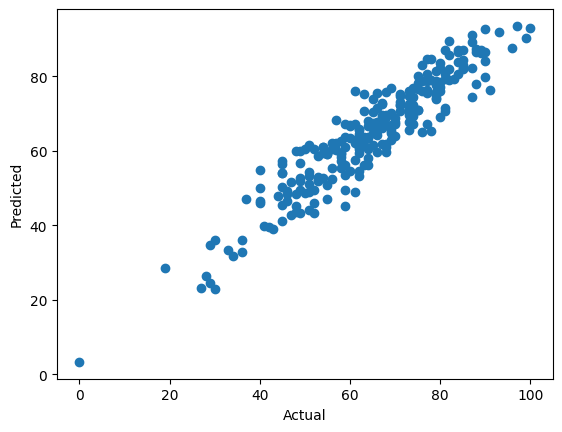

In [40]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

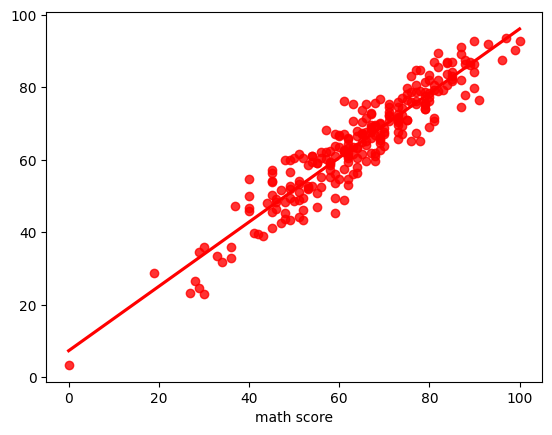

In [41]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');